In [ ]:
%matplotlib inline
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib
matplotlib.rcParams.update({'font.size': 14})

#### Применение SVD к матрице значений функции на 2-мерной сетке

Разложение по сингулярным значениям (SVD) - это разложение вещественной или комплексной матрицы на три множителя:
- матрица вращения/поворота
- диагональная матрица масштабирования (матрица сингулярных значений)
- матрица вращения/поворота

Для гладких функций сингулярные числа такой матрицы всегда будут быстро "затухать"

Text(0.5, 0, 'y')

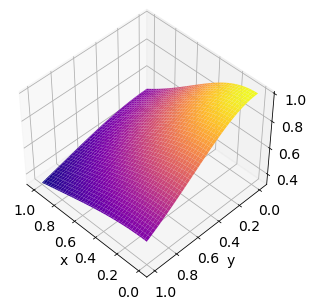

In [ ]:
import numpy as np
n = 128
t = np.linspace(0, 1, n)
x, y = np.meshgrid(t, t)
f = 1/(x**2 + y**2 + 1)
# f = np.sin(10*x/(y+1)**2)**2 * np.cos(1*(x-0.5)+ 8*y)**3
fig = plt.figure(figsize = (10,5))
ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.view_init(45, 135)
ax.plot_surface(x, y, f, cmap = 'plasma')
ax.set_xlabel('x')
ax.set_ylabel('y')

Построим график зависимости сингулярных чисел от номера в логарифмической шкале

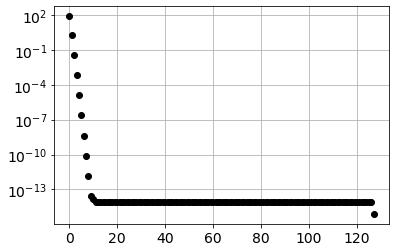

In [ ]:
u, s, v = np.linalg.svd(f)
plt.semilogy(s,'ko')
plt.grid(True)

Оставим несколько первых сингулярных чисел, возьмём обрезанное разложение, и посчитаем ошибку

error = 3.49e-14


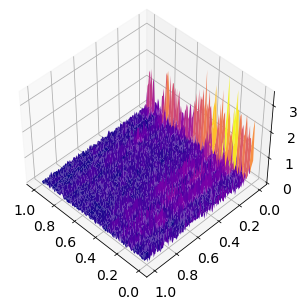

In [ ]:
r = 10
ur = u[:, :r]
sr = s[:r]
vr = v[:r, :] # Транспонированная матрица
fappr = ur @ np.diag(sr) @ vr
er = np.linalg.norm(fappr - f, 'fro')
print('error = {0:5.2e}'.format(er))
fig = plt.figure(figsize = (10,5))
ax2 = fig.add_subplot(1, 1, 1, projection='3d')
ax2.view_init(45, 135)
#ax2.plot_surface(x, y, fappr, cmap = 'plasma')
ax2.plot_surface(x, y, np.abs(fappr-f), cmap = 'plasma')

In [ ]:
np.abs(fappr-f).max()

3.4416913763379853e-15

#### Сжатие изображений

C:\Users\tsarina\AppData\Local\Temp/ipykernel_13780/3757312545.py:4: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  picture = imageio.imread('img/Koala.jpg')


(768, 1024, 3) uint8


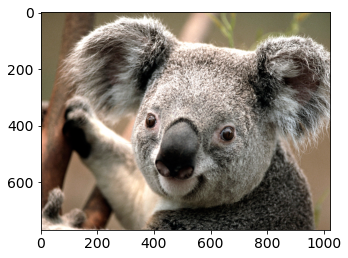

In [ ]:
from scipy import ndimage
import imageio
# Читаем файл в многомерный массив
picture = imageio.imread('img/Koala.jpg')
print(picture.shape, picture.dtype) # размеры и тип
plt.imshow(picture)

93 10.145337919874443 113994.83321003486
108 8.683665203397732 104738.2978160252
126 10.571434097178129 93977.73351929877
average error =  0.028146907816867073 
max error =  255


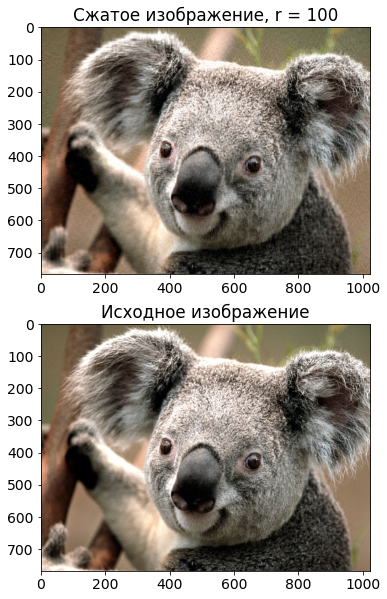

In [ ]:
face_appr = np.zeros(shape = picture.shape, dtype = float)
r = 100 # max(face.shape[0:1])
for i in range(0, picture.shape[-1]):
    u, s, v = np.linalg.svd(picture[:,:,i])
    #print(s)
    print(np.sum(s > s.max()*0.01), s.min(), s.max())
    u_r = u[:, :r]
    s_r = s[:r]
    v_r = v[:r, :]
    face_appr[:,:,i] = u_r.dot(np.diag(s_r).dot(v_r))
face_appr = np.clip(np.rint(face_appr), 0, 255)
face_appr = face_appr.astype('uint8')
error = picture - face_appr

fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (20,10))
ax2.imshow(picture)
ax2.set_title('Исходное изображение')
ax1.set_title('Сжатое изображение, r = ' + str(r))
ax1.imshow(face_appr)
print('average error = ',
      (np.sum(error**2)/(picture.shape[0] * picture.shape[1] * 3))**(0.5)/255,
      '\nmax error = ', np.max(error))